# import the dependencies

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn import metrics

# data collection and peprocessing

In [2]:
#loading the dataset csv file to the pandas dataframe
df = pd.read_csv("car data.csv")

In [3]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
df.shape

(301, 9)

In [5]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.isnull().sum()

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

In [8]:
#checking the distribution of categorical data

print(df.Fuel_Type.value_counts())
print(df.Seller_Type.value_counts())
print(df.Transmission.value_counts())

Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64
Seller_Type
Dealer        195
Individual    106
Name: count, dtype: int64
Transmission
Manual       261
Automatic     40
Name: count, dtype: int64


# encoding the categorical data

In [9]:
#encoding the fuel column
df.replace({"Fuel_Type":{"Petrol":0 , "Diesel":1 , "CNG":2}},inplace = True)

C:\Users\badgu\AppData\Local\Temp\ipykernel_26472\14316796.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Fuel_Type":{"Petrol":0 , "Diesel":1 , "CNG":2}},inplace = True)


In [10]:
#encoding the Seller column
df.replace({"Seller_Type":{"Dealer":0 , "Individual":1}},inplace = True)

C:\Users\badgu\AppData\Local\Temp\ipykernel_26472\2646979013.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Seller_Type":{"Dealer":0 , "Individual":1}},inplace = True)


In [11]:
#encoding the Transmission column
df.replace({"Transmission":{"Manual":0 , "Automatic":1}},inplace = True)

C:\Users\badgu\AppData\Local\Temp\ipykernel_26472\712780706.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({"Transmission":{"Manual":0 , "Automatic":1}},inplace = True)


In [12]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,0,0,0,0
1,sx4,2013,4.75,9.54,43000,1,0,0,0
2,ciaz,2017,7.25,9.85,6900,0,0,0,0
3,wagon r,2011,2.85,4.15,5200,0,0,0,0
4,swift,2014,4.60,6.87,42450,1,0,0,0


# train test split the data

In [13]:
X = df.drop(["Car_Name" , "Selling_Price"] , axis = 1)
Y = df["Selling_Price"]

In [14]:
print(X)
print(Y)

     Year  Present_Price  Kms_Driven  Fuel_Type  Seller_Type  Transmission  \
0    2014           5.59       27000          0            0             0   
1    2013           9.54       43000          1            0             0   
2    2017           9.85        6900          0            0             0   
3    2011           4.15        5200          0            0             0   
4    2014           6.87       42450          1            0             0   
..    ...            ...         ...        ...          ...           ...   
296  2016          11.60       33988          1            0             0   
297  2015           5.90       60000          0            0             0   
298  2009          11.00       87934          0            0             0   
299  2017          12.50        9000          1            0             0   
300  2016           5.90        5464          0            0             0   

     Owner  
0        0  
1        0  
2        0  
3        0 

In [15]:
#train test split
X_train , X_test , Y_train , Y_test = train_test_split(
    X , Y , test_size = 0.2 , random_state = 42
)

In [16]:
#model training {Linear regression model}

lr = LinearRegression()

In [17]:
lr.fit(X_train , Y_train)


LinearRegression()

# model evaluation

In [18]:
#prediction on training data

pred_for_training_data = lr.predict(X_train)

In [19]:
# R square error

r2_score = metrics.r2_score(Y_train , pred_for_training_data)
print("r2_score:",r2_score)

r2_score: 0.8839793496750799


# visualize actual prices and predicted prices

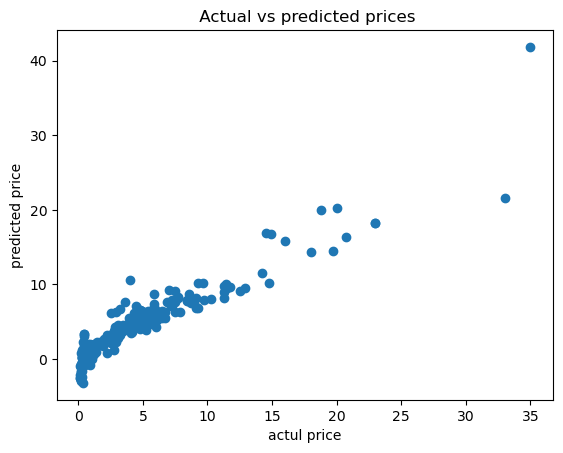

In [20]:
plt.scatter(Y_train , pred_for_training_data)
plt.xlabel("actul price")
plt.ylabel("predicted price")
plt.title(" Actual vs predicted prices")
plt.show()

In [21]:
#prediction on test data

pred_for_testing_data = lr.predict(X_test)

In [22]:
# R square error

r2_score = metrics.r2_score(Y_test , pred_for_testing_data)
print("r2_score:",r2_score)

r2_score: 0.846805395765359


# visualize actual prices and predicted prices

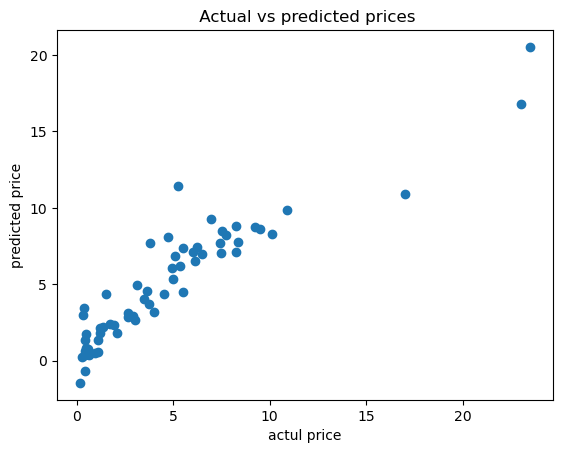

In [23]:
plt.scatter(Y_test , pred_for_testing_data)
plt.xlabel("actul price")
plt.ylabel("predicted price")
plt.title(" Actual vs predicted prices")
plt.show()

In [24]:
input_data = (2016,10.79,43000,1,0,0,0)

input_as_np_array = np.asarray(input_data)

input_data_reshaped = input_as_np_array.reshape(1,-1)

prediction = lr.predict(input_data_reshaped)
print(prediction)

[8.21516023]


C:\Users\badgu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# Lasso Regression

In [25]:
#model training {Linear regression model}

ls = Lasso()

In [26]:
ls.fit(X_train , Y_train)

Lasso()

In [27]:
#prediction on training data

pred_for_training_data = ls.predict(X_train)

In [28]:
# R square error

r2_score = metrics.r2_score(Y_train , pred_for_training_data)
print("r2_score:",r2_score)

r2_score: 0.8480302868137157


# visualize actual prices and predicted prices

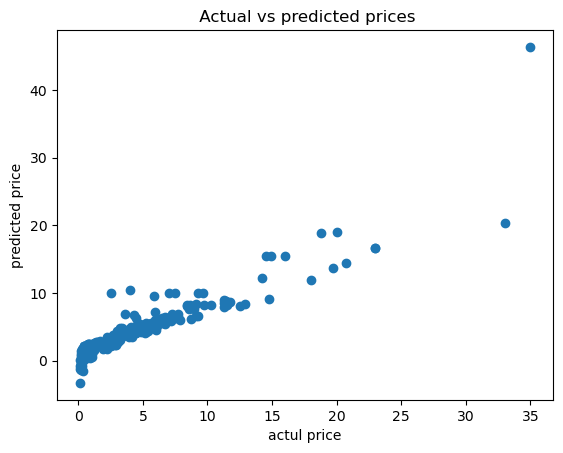

In [29]:
plt.scatter(Y_train , pred_for_training_data)
plt.xlabel("actul price")
plt.ylabel("predicted price")
plt.title(" Actual vs predicted prices")
plt.show()

In [30]:
#prediction on test data

pred_for_testing_data = ls.predict(X_test)

In [31]:
# R square error

r2_score = metrics.r2_score(Y_test , pred_for_testing_data)
print("r2_score:",r2_score)

r2_score: 0.7985512461284692


# visualize actual prices and predicted prices

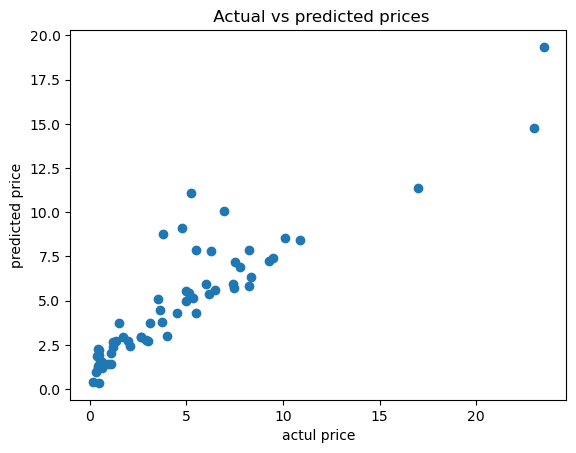

In [32]:
plt.scatter(Y_test , pred_for_testing_data)
plt.xlabel("actul price")
plt.ylabel("predicted price")
plt.title(" Actual vs predicted prices")
plt.show()

In [33]:
input_data = (2016,10.79,43000,1,0,0,0)

input_as_np_array = np.asarray(input_data)

input_data_reshaped = input_as_np_array.reshape(1,-1)

prediction = ls.predict(input_data_reshaped)
print(prediction)

[6.9263973]


C:\Users\badgu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but Lasso was fitted with feature names
  warnings.warn(
